In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
df=pd.read_csv("gurgaon_properties_cleaned_v2.csv")

In [129]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,...,NaN,2250.0,NaN,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,...,2350.0,NaN,NaN,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,6228.0,Plot area 692(578.6 sq.m.),4,4,3+,...,NaN,6228.0,NaN,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,2,...,NaN,750.0,650.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,1424.0,Carpet area: 1424 (132.29 sq.m.),2,2,3+,...,NaN,NaN,1424.0,0,0,0,0,0,0,63


In [130]:
df.shape

(3805, 23)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3805 entries, 0 to 3804
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3805 non-null   object 
 1   society              3804 non-null   object 
 2   sector               3805 non-null   object 
 3   price                3788 non-null   float64
 4   price_per_sqft       3788 non-null   float64
 5   area                 3788 non-null   float64
 6   areaWithType         3805 non-null   object 
 7   bedRoom              3805 non-null   int64  
 8   bathroom             3805 non-null   int64  
 9   balcony              3805 non-null   object 
 10  floorNum             3786 non-null   float64
 11  facing               2700 non-null   object 
 12  agePossession        3805 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1736 non-null   float64
 15  carpet_area          1946 non-null   f

In [132]:
df.duplicated().sum()

np.int64(127)

In [133]:
df.drop_duplicates(inplace=True)

## **property_type**

<Axes: xlabel='property_type'>

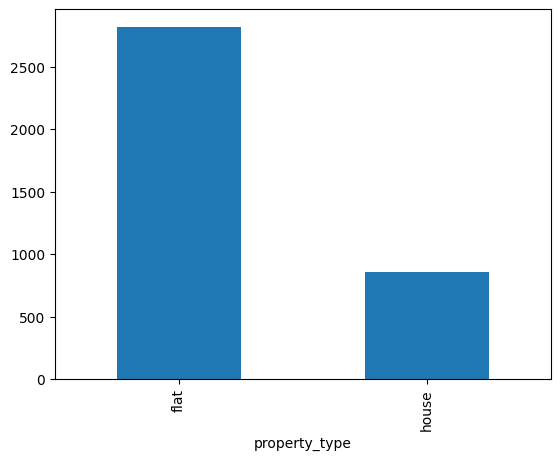

In [134]:
df['property_type'].value_counts().plot(kind='bar')

### **Observation**

*   Flats are in majority(~75%) and there are less number of houses(\~25%)
*   No missing values



## **society**

In [135]:
df['society'].value_counts().shape

(682,)

In [136]:
df['society'].value_counts()

,count
society,
independent,486
tulip violet,75
ss the leaf,73
shapoorji pallonji joyville gurugram,42
signature global park,35
...,...
landmark house,1
hector trimurti heights,1
unitech south park,1


In [137]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

,proportion
society,
tulip violet,0.023504
ss the leaf,0.046380
shapoorji pallonji joyville gurugram,0.059542
signature global park,0.070511
dlf new town heights,0.081166
...,...
ansal heights 86,0.487308
puri emerald bay,0.491382
umang winter hills,0.495456


In [138]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins={"Very High (>100)" : (society_counts > 100).sum(),
                "High (50-100)" : ((society_counts <= 100)&(society_counts >= 50)).sum(),
                "Avarage (10-49)" : ((society_counts >= 10)&(society_counts < 50)).sum(),
                "Low (2-9)" : ((society_counts >= 2)&(society_counts < 10)).sum(),
                "Very Low (1)" : (society_counts == 1).sum()}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Avarage (10-49)': np.int64(92),
 'Low (2-9)': np.int64(274),
 'Very Low (1)': np.int64(313)}

<Axes: xlabel='society'>

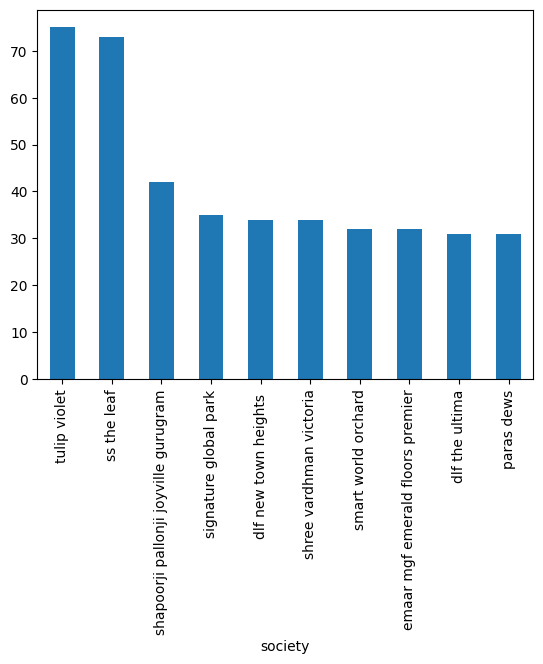

In [139]:
# top 10 societies
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [140]:
df['society'].isnull().sum()

np.int64(1)

In [141]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2031,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


### **Observation**

*   Around 13% comes under independent tag.
*   There are 681 societies.
*   The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 606 societies
    *  Very High (>100) : Only 1 society has more than 100 listings.
    *  High (50-100) : 2 societies have between 50 to 100 listings.
    *  Average (10-49) : 92 societies fall in this range with 10 to 49 listings each.
    *  Low (2-9) : 273 societies have between 2 to 9 listings.
    *  Very Low (1) : A significant number, 308 societies have only 1 listing.
*  1 missing value

## **Price**

In [142]:
df['price'].isnull().sum()

np.int64(16)

In [143]:
df['price'].describe()

,price
count,3662.000000
mean,2.532840
std,2.980018
min,0.070000
25%,0.950000
50%,1.520000
75%,2.750000
max,31.500000


<Axes: xlabel='price', ylabel='Count'>

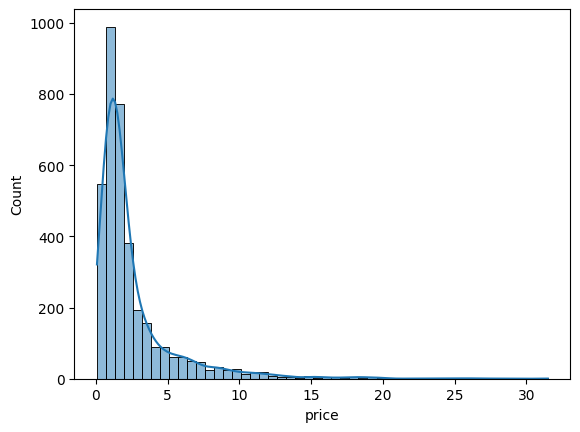

In [144]:
sns.histplot(df['price'],kde=True,bins=50)

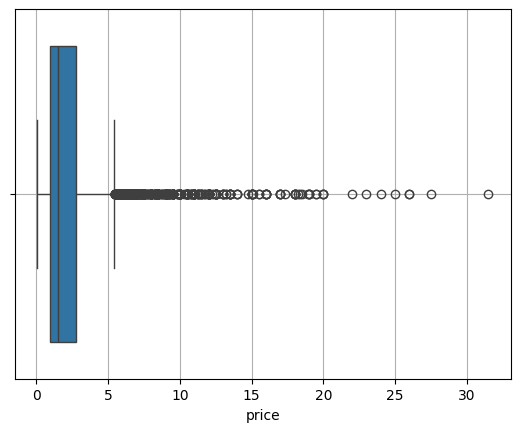

In [145]:
sns.boxplot(x=df['price'])
plt.grid()



*   Descriptive Statistics :
    * Count: There are 3,662 non-missing price entries.
    * Mean Price: The average price is approximately 2.53 crores.
    * Median Price: The median (or 50th percentile) price is 1.52 crores.
    * Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
    * Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    * IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
*   Visualizations :
    * Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    * Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
* Missing Values: There are 16 missing values in the price column.

In [146]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2801358362204383 14.94180520711952


**Skewness** : The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis** : The kurtosis value is approximately 14.94. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [147]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01,0.05,0.95,0.99])
quantiles

,price
0.01,0.250
0.05,0.370
0.95,8.500
0.99,15.256


Quantile Analysis :

*   1% Quantile: Only 1% of properties are priced below 0.25 crores.
*   5% Quantile: 5% of properties are priced below 0.37 crores.
*   95% Quantile: 95% of properties are priced below 8.5 crores.
*   99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.



In [148]:
# Identify potential outliers using IQR method
Q1=df['price'].describe()['25%']
Q3=df['price'].describe()['75%']
IQR=Q3-Q1

IQR

np.float64(1.8)

In [149]:
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

print(lower_bound,upper_bound)

-1.7500000000000002 5.45


In [150]:
outliers=df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [151]:
outliers['price'].describe()

,price
count,425.000000
mean,9.235624
std,4.065259
min,5.460000
25%,6.460000
50%,8.000000
75%,10.750000
max,31.500000


Outliers Analysis (using IQR method):


*   Based on the IQR method, there are 425 properties considered as outliers.
*   These outliers have an average price of approximately 9.24 crores.
*   The range for these outliers is from 5.46 crores to 31.5 crores.





<Axes: xlabel='price'>

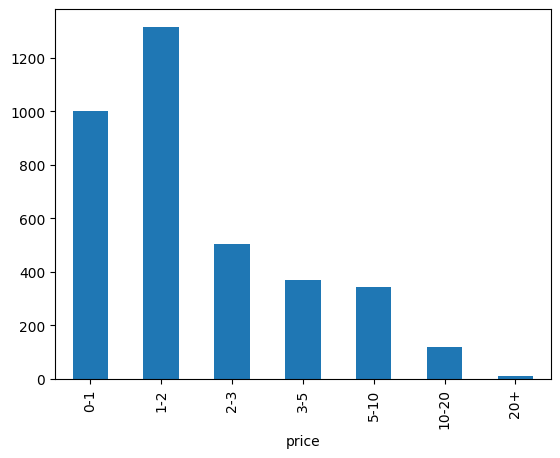

In [152]:
# price binning
bins =[0,1,2,3,5,10,20,50]
bins_lavel=["0-1","1-2","2-3","3-5","5-10","10-20","20+"]
pd.cut(df['price'],bins=bins,labels=bins_lavel,right=False).value_counts().sort_index().plot(kind='bar')

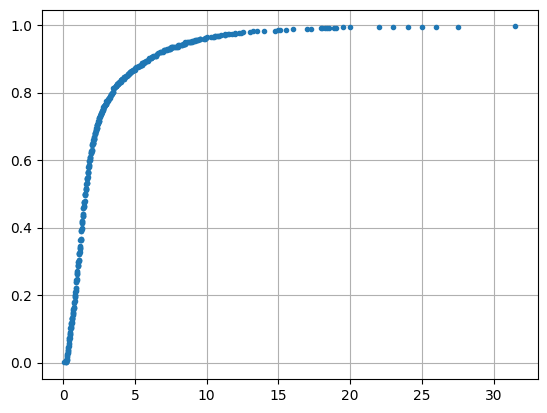

In [153]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

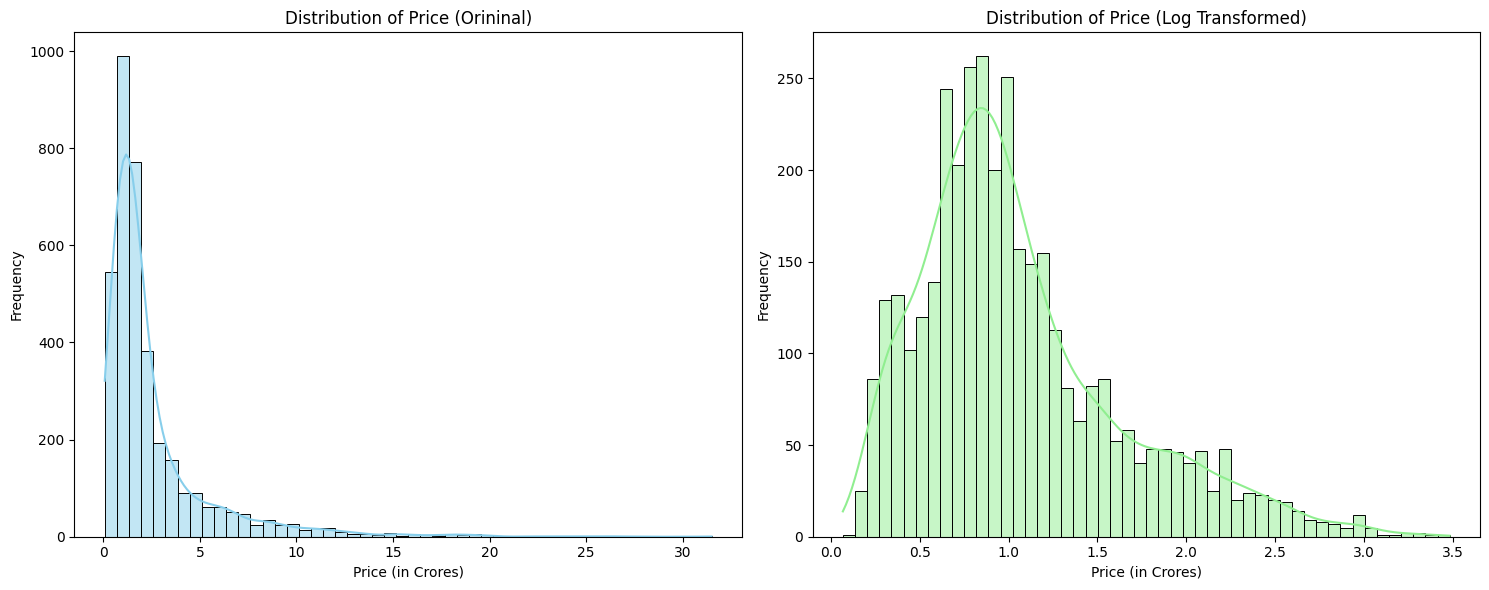

In [154]:
plt.figure(figsize=(15,6))

# Distribution plot without log transformation
plt.subplot(1,2,1)
sns.histplot(df['price'],kde=True,bins=50,color='skyblue')
plt.title('Distribution of Price (Orininal)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price']),kde=True,bins=50,color='lightgreen')
plt.title('Distribution of Price (Log Transformed)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [155]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.074911753779757 0.9667273044405307


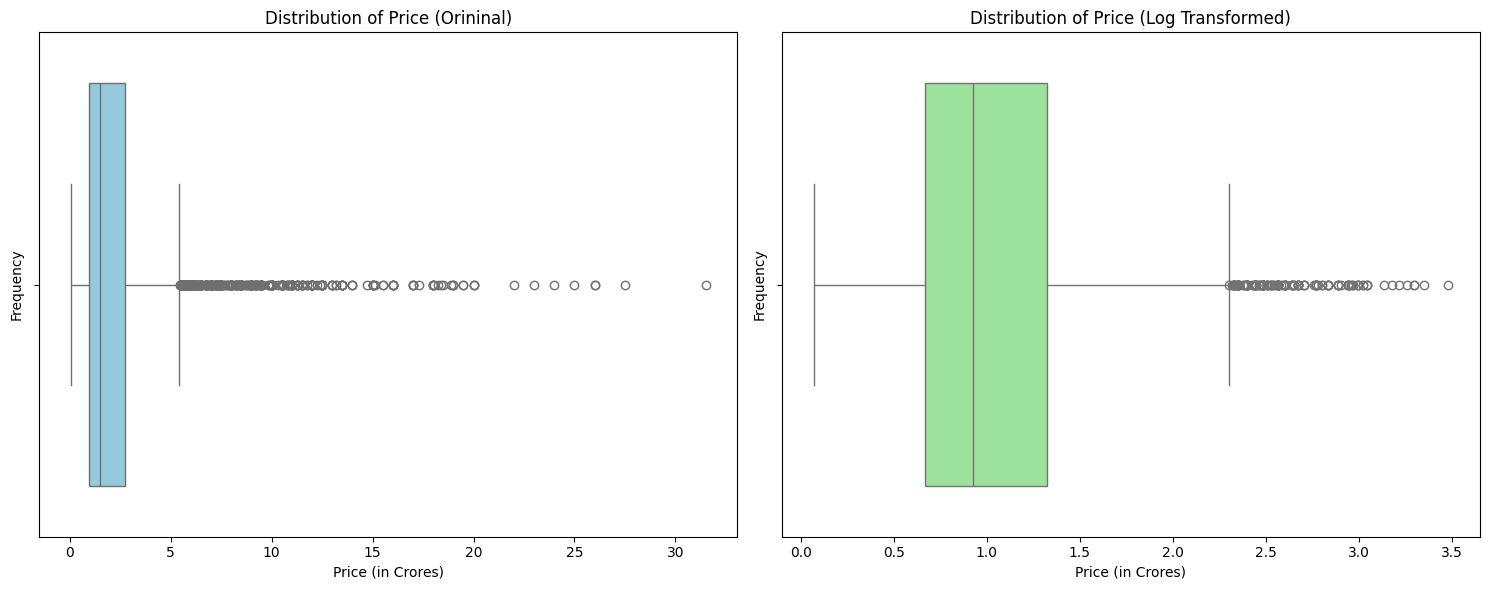

In [196]:
plt.figure(figsize=(15,6))

# Distribution plot without log transformation
plt.subplot(1,2,1)
sns.boxplot(x=df['price'],color='skyblue')
plt.title('Distribution of Price (Orininal)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1,2,2)
sns.boxplot(x=np.log1p(df['price']),color='lightgreen')
plt.title('Distribution of Price (Log Transformed)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### **price_per_sqft**

In [157]:
df['price_per_sqft'].isnull().sum()

np.int64(16)

In [158]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3662.000000
mean,13890.225560
std,23204.026603
min,4.000000
25%,6818.000000
50%,9020.000000
75%,13877.250000
max,600000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

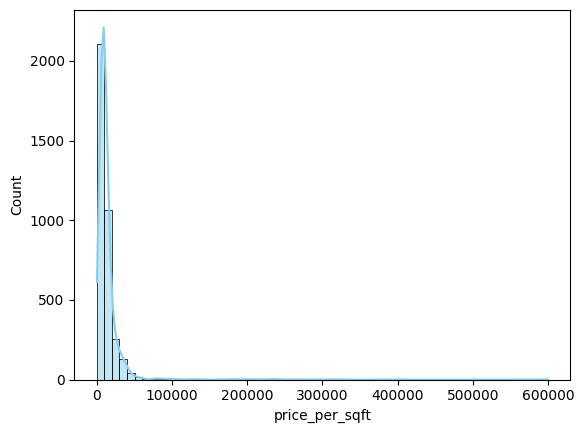

In [159]:
sns.histplot(df['price_per_sqft'],bins=60,color='skyblue',kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: xlabel='price_per_sqft'>

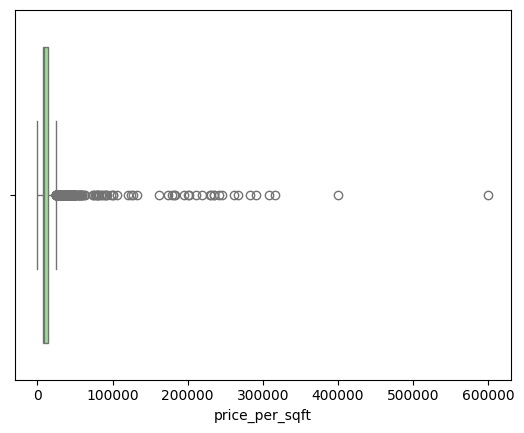

In [160]:
sns.boxplot(x=df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

**Observations**



*   Potential Outliers
*   Right Skewed
*   16 missing values

## **bedRoom**

In [161]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

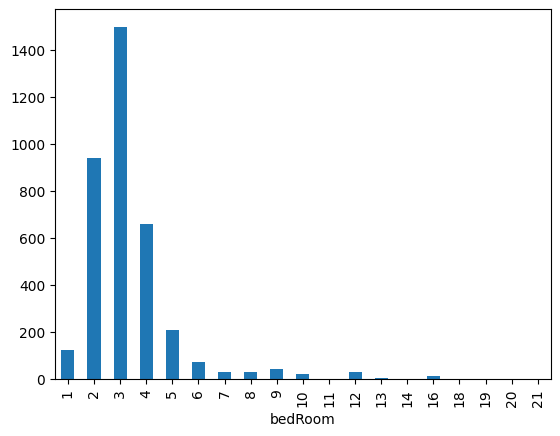

In [162]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

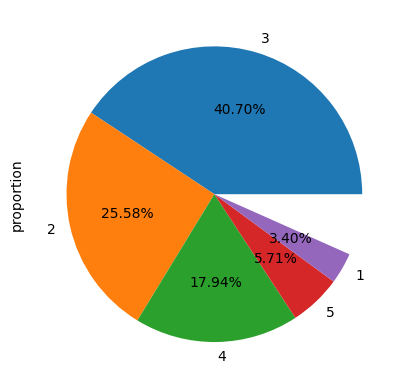

In [163]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%',normalize=False)

In [164]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,...,NaN,2250.0,NaN,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,...,2350.0,NaN,NaN,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,6228.0,Plot area 692(578.6 sq.m.),4,4,3+,...,NaN,6228.0,NaN,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,2,...,NaN,750.0,650.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,1424.0,Carpet area: 1424 (132.29 sq.m.),2,2,3+,...,NaN,NaN,1424.0,0,0,0,0,0,0,63


## **balcony**

In [165]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

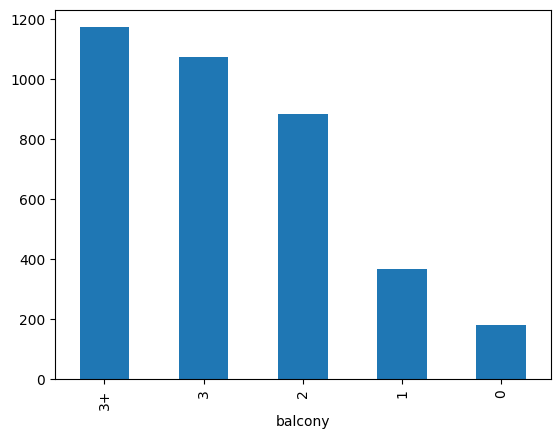

In [166]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

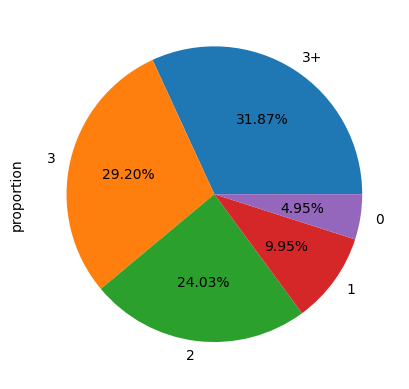

In [167]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

## **floorNum**

In [168]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,2.0,South-East,Old Property,NaN,2250.0,NaN,0,0,0,0,0,0,27
1,9.0,South-West,Moderately Old,2350.0,NaN,NaN,0,1,0,1,0,1,149
2,2.0,North-East,New Property,NaN,6228.0,NaN,0,1,0,1,0,0,130
3,9.0,East,Undefined,NaN,750.0,650.0,0,0,0,0,0,0,0
4,12.0,NaN,Undefined,NaN,NaN,1424.0,0,0,0,0,0,0,63


In [169]:
df['floorNum'].isnull().sum()

np.int64(19)

In [170]:
df['floorNum'].describe()

,floorNum
count,3659.000000
mean,6.796392
std,6.011592
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


<Axes: xlabel='floorNum'>

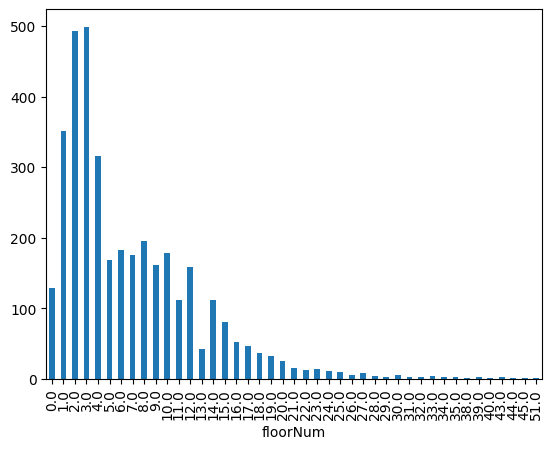

In [171]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

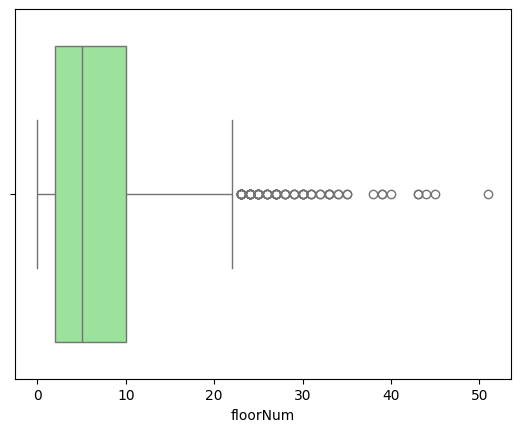

In [172]:
sns.boxplot(x=df['floorNum'], color='lightgreen')



*   The majority of the properties lie between the ground floor (0) and the 25th floor.
*   Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
*   There are a few properties located at higher floors, but their frequency is much lower.
*   The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
*   Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.



## **facing**

In [173]:
df['facing'].isnull().sum()

np.int64(1045)

In [174]:
df['facing'].fillna('NA',inplace=True)

/tmp/ipykernel_5331/3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [175]:
df['facing'].value_counts()

,count
facing,
NA,1045
North-East,624
East,622
North,387
West,249
South,231
North-West,193
South-East,174
South-West,153


## **agePossession**

In [176]:
df['agePossession'].isnull().sum()

np.int64(0)

In [177]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1646
New Property,593
Moderately Old,563
Undefined,308
Old Property,303
Under Construction,265


## **areas**

In [178]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1803)

In [179]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1875.000000
mean,1925.237627
std,764.172177
min,89.000000
25%,1479.500000
50%,1828.000000
75%,2215.000000
max,10000.000000


<Axes: xlabel='super_built_up_area', ylabel='Count'>

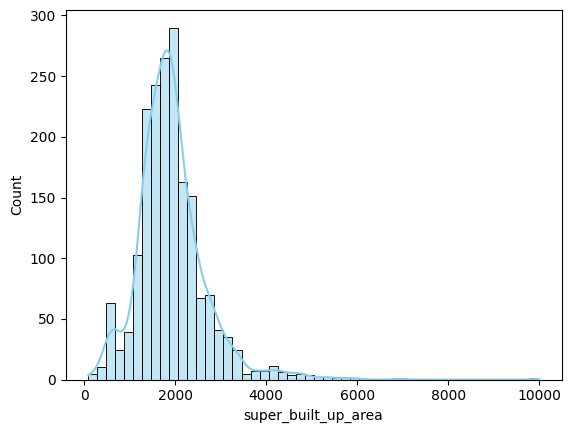

In [180]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: xlabel='super_built_up_area'>

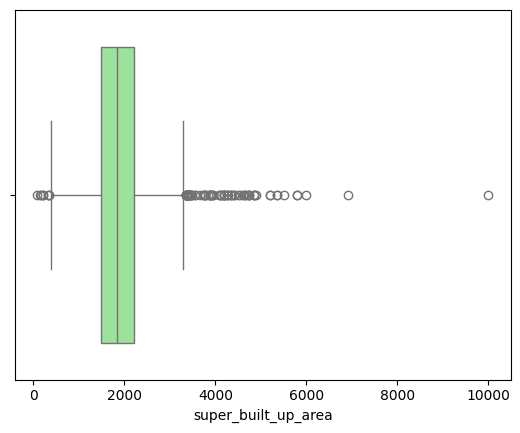

In [181]:
sns.boxplot(x=df['super_built_up_area'].dropna(), color='lightgreen')



*   Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
*   There are a few properties with a significantly larger area, leading to a right-skewed distribution.
*   The interquartile range (IQR) lies between roughly 1,479 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
*   There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.





In [182]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1986)

In [183]:
df['built_up_area'].describe()

,built_up_area
count,1692.000000
mean,2378.152499
std,17932.318033
min,2.000000
25%,1100.000000
50%,1650.000000
75%,2400.000000
max,737147.000000


<Axes: xlabel='built_up_area', ylabel='Count'>

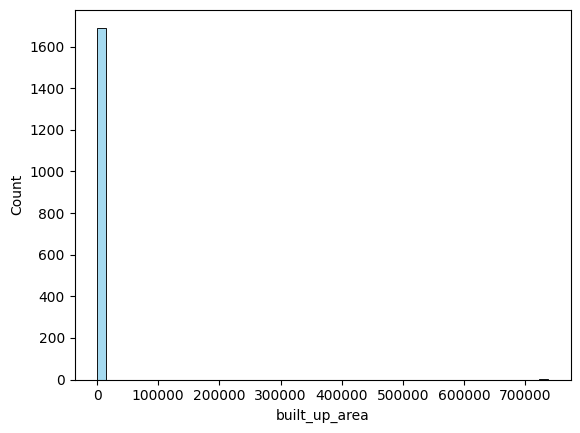

In [184]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='built_up_area'>

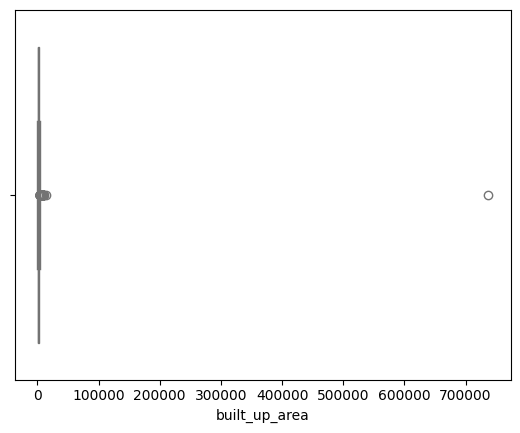

In [185]:
sns.boxplot(x=df['built_up_area'].dropna(), color='lightgreen')


*   Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
*   There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
*   The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

## **additional rooms**

In [186]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,0,27
1,0,1,0,1,0,1,149
2,0,1,0,1,0,0,130
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,63
...,...,...,...,...,...,...,...
3800,1,0,0,0,0,0,72
3801,0,1,0,0,0,2,70
3802,0,1,1,1,0,0,24
3803,0,0,0,0,0,2,26


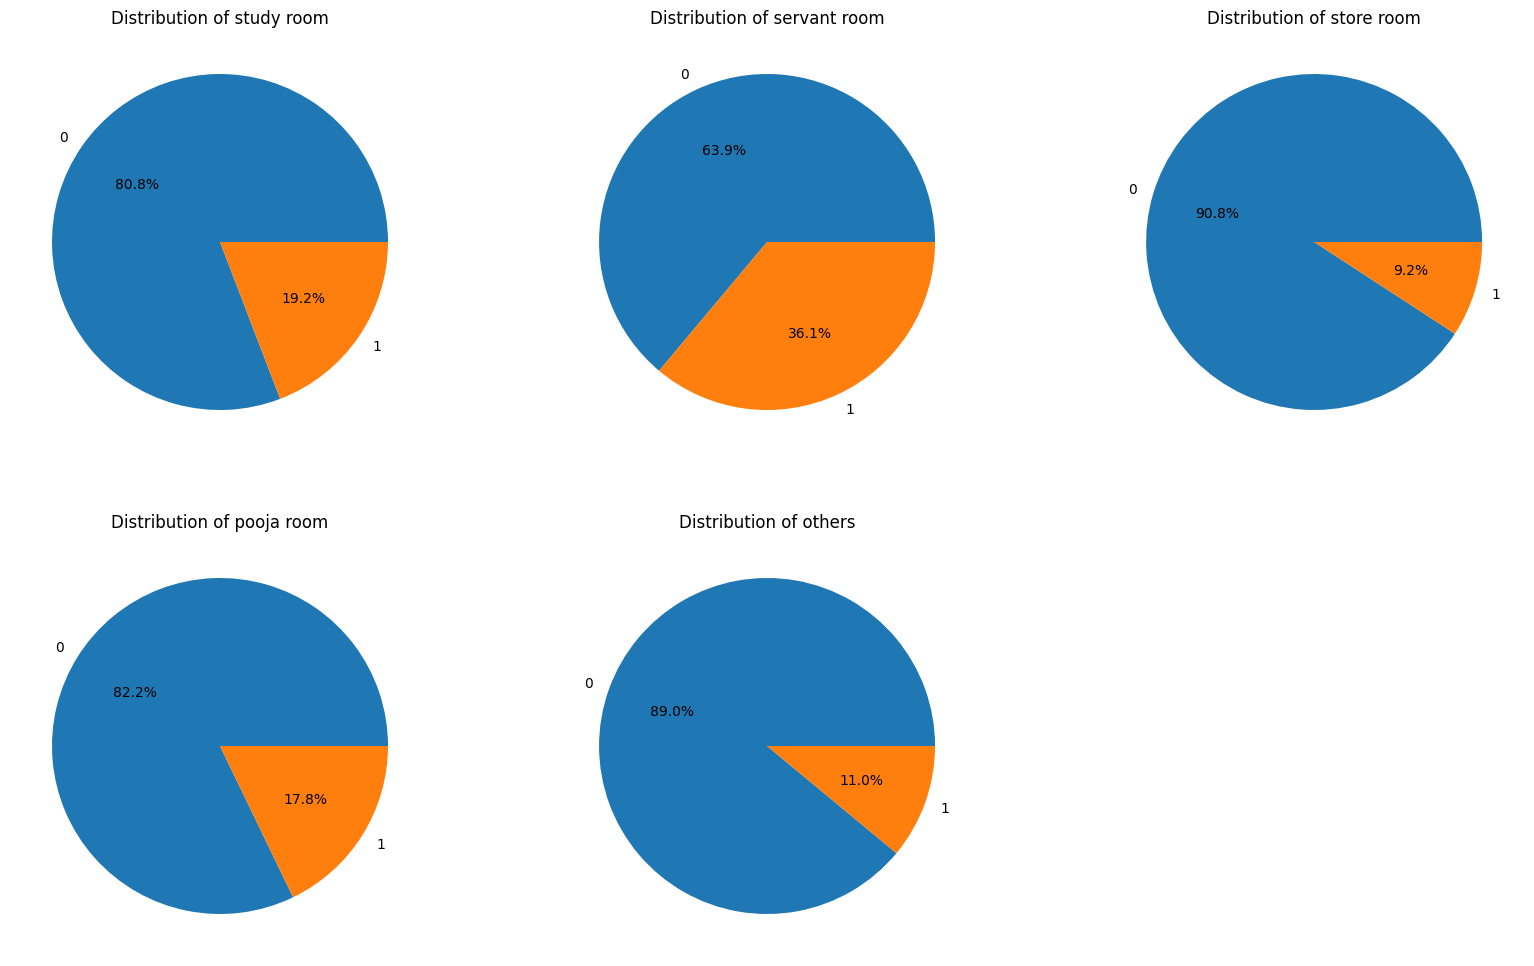

In [193]:
plt.figure(figsize=(20,12))
rooms=['study room','servant room','store room','pooja room','others']
idx=0
for room in rooms:
  idx+=1
  plt.subplot(2,3,idx)
  df[room].value_counts().plot(kind='pie',autopct='%1.1f%%')
  plt.title(f"Distribution of {room}")
  plt.ylabel('')
plt.show()

## **furnishing_type**

In [197]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
0,2412
1,1059
2,207


<Axes: ylabel='count'>

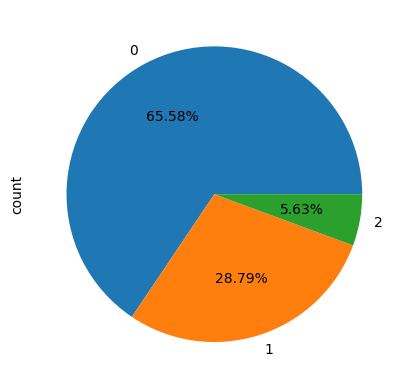

In [198]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

## **luxury_score**

In [199]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [200]:
df['luxury_score'].describe()

,luxury_score
count,3678.000000
mean,71.446982
std,53.088381
min,0.000000
25%,31.000000
50%,59.000000
75%,110.000000
max,174.000000


<Axes: xlabel='luxury_score', ylabel='Count'>

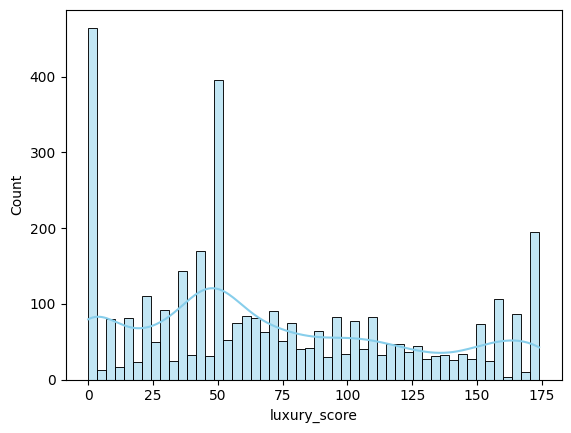

In [201]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

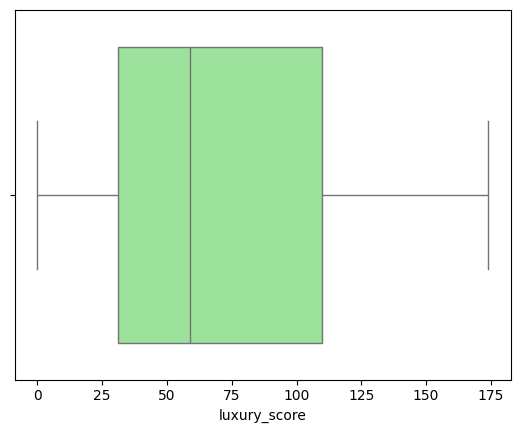

In [203]:
sns.boxplot(x=df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [204]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,...,NaN,2250.0,NaN,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,...,2350.0,NaN,NaN,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,6228.0,Plot area 692(578.6 sq.m.),4,4,3+,...,NaN,6228.0,NaN,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,2,...,NaN,750.0,650.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,1424.0,Carpet area: 1424 (132.29 sq.m.),2,2,3+,...,NaN,NaN,1424.0,0,0,0,0,0,0,63
